# Introduction to Machine Learning Methodology
### Applied to Physics Simulation Data (Reactor Code)

**Reference resources:**
- scikit-learn MOOC: https://inria.github.io/scikit-learn-mooc/
- Olivier's thesis: https://theses.hal.science/tel-04877060

**Nomenclature:** `X` for inputs, `Y` for outputs.

## Summary

| Step | Action | Key point |
|---|---|---|
| **0** | Visualize raw data | Always, no exceptions |
| **1** | Correlation heatmap + Pearson r/p | Remove non-influential X; Pearson = linear only |
| **2** | Outlier detection on residuals | **Critical step** |
| **3-4** | Split → normalize X (Pipeline) **and Y** | Fit scalers on train only; no data leakage |
| **5** | SVD on normalized Y | Measure intrinsic dimensionality |
| **6** | Ridge + alpha sweep | Train on scaled Y; evaluate R² in physical units |
| **7** | Residual histogram | Gaussian centered residuals → valid model |
| **8** | `model.predict` + `inverse_transform` | Never return scaled output to the user |

---


## Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score

## Data Generation — Simulating a physical Code

We simulate a code producing two correlated outputs:
- **Y1 ~ X²** (quadratic relationship + Gaussian noise)
- **Y2 ~ 0.5 × Y1** (output correlated with Y1)

Two realistic pollution types are injected:
1. **X_trash**: an input with no physical link to the outputs
2. **Outliers** at indices 20, 100, 250: non-convergence artifacts from the code


In [2]:
np.random.seed(42)
n_samples = 300
X_phys = np.linspace(0, 10, n_samples).reshape(-1, 1)

# Physics: Y1 ~ X², Y2 correlated with Y1
Y1_clean = (X_phys**2).flatten() + np.random.normal(0, 0.5, n_samples)
Y2_clean = (0.5 * Y1_clean) + np.random.normal(0, 1, n_samples)

# Injected pollutions
X_trash = np.random.normal(0, 1, (n_samples, 1))
Y1_polluted, Y2_polluted = Y1_clean.copy(), Y2_clean.copy()
outlier_idx = [20, 100, 250]
Y1_polluted[outlier_idx] += [15, -12, 18]   # Non-convergence artifacts
Y2_polluted[outlier_idx] += [-8, 10, -6]

X_full  = np.hstack([X_phys, X_trash])
Y_multi = np.column_stack([Y1_polluted, Y2_polluted])
df = pd.DataFrame(
    np.hstack([X_full, Y_multi]),
    columns=['X_phys', 'X_trash', 'Y1', 'Y2']
)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (300, 4)


,X_phys,X_trash,Y1,Y2
0,0.000000,0.756989,0.248357,-0.704816
1,0.033445,-0.922165,-0.068014,-0.594188
2,0.066890,0.869606,0.328318,0.911453
3,0.100334,1.355638,0.771582,0.996161
4,0.133779,0.413435,-0.099180,-0.070491


## Step 0 — Visualize Raw Data First

Always look at your data before running any statistics. Here, the outliers are already visible to the naked eye.


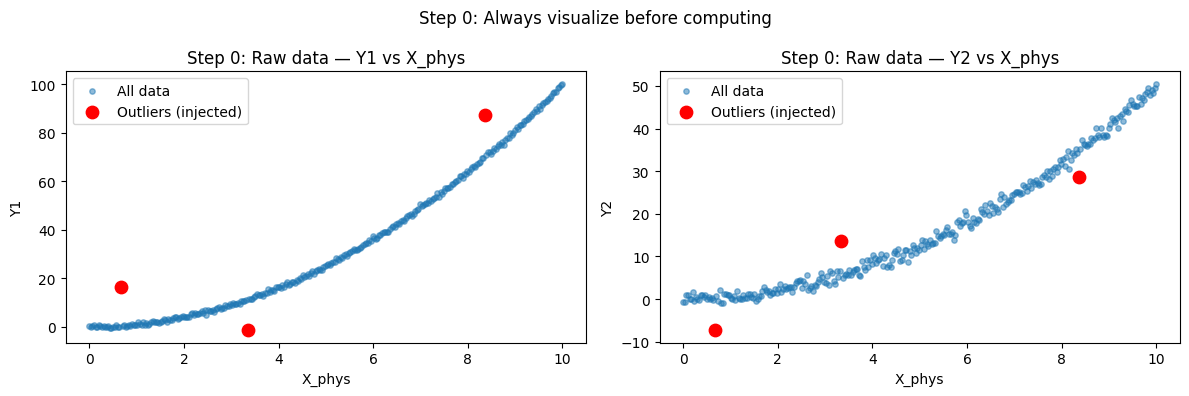

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, (yi, label) in enumerate(zip([Y1_polluted, Y2_polluted], ['Y1', 'Y2'])):
    axes[i].scatter(X_phys, yi, alpha=0.5, s=15, label='All data')
    axes[i].scatter(X_phys[outlier_idx], yi[outlier_idx],
                    color='red', s=80, zorder=5, label='Outliers (injected)')
    axes[i].set_title(f'Step 0: Raw data — {label} vs X_phys')
    axes[i].set_xlabel('X_phys')
    axes[i].set_ylabel(label)
    axes[i].legend()
plt.suptitle("Step 0: Always visualize before computing")
plt.tight_layout()
plt.show()

## Step 1 — Dependency Analysis & Feature Selection

Two complementary tools:

| Tool | What it measures |
|---|---|
| Correlation heatmap | Quick visual overview of all pairwise correlations |
| **Pearson r + p-value** | Strength AND statistical significance of each feature-output relationship |

**Pearson reminder:**
- `r` ∈ [-1, +1]: strength and direction of the linear correlation
- `p-value` tests H₀: *"r = 0"* (no linear correlation)
- p < 0.05 → reject H₀, the correlation is statistically significant

> ⚠️ **Pearson limitation:** it only captures **linear** relationships. A feature quadratically linked to Y may show r ≈ 0. For non-linear effects, complement with a variable importance analysis (e.g. Random Forest).


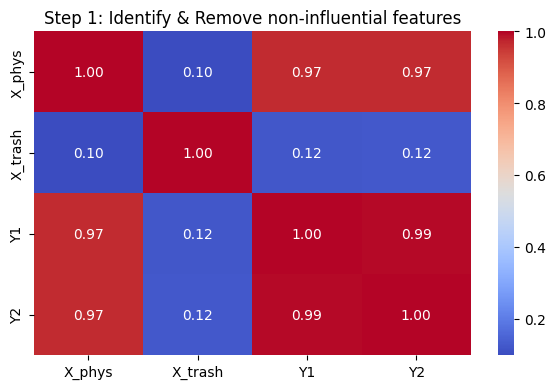

In [4]:
# Correlation heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Step 1: Identify & Remove non-influential features")
plt.tight_layout()
plt.show()

In [5]:
# Pearson r + p-value for each feature-output pair
features = ['X_phys', 'X_trash']
targets  = ['Y1', 'Y2']

print(f"  {'Feature':<10} {'Target':<8} {'r':>8}   {'p-value':>12}   {'Significant?'}")
print("  " + "-" * 62)
for feat in features:
    for tgt in targets:
        r, p = stats.pearsonr(df[feat], df[tgt])
        sig = "YES" if p < 0.05 else "no"
        print(f"  {feat:<10} {tgt:<8} {r:>+8.4f}   {p:>12.2e}   {sig}")

print()
print("WARNING: X_trash appears borderline significant because injected outliers")
print("         inflate its correlation artificially. It will vanish after Step 2.")

  Feature    Target          r        p-value   Significant?
  --------------------------------------------------------------
  X_phys     Y1        +0.9660      5.05e-177   YES
  X_phys     Y2        +0.9650      2.59e-175   YES
  X_trash    Y1        +0.1224       3.40e-02   YES
  X_trash    Y2        +0.1243       3.14e-02   YES

         inflate its correlation artificially. It will vanish after Step 2.


In [6]:
# Decision: remove X_trash
X_selected = df[["X_phys"]].values
print("-> X_trash removed. Keeping X_phys only.")

-> X_trash removed. Keeping X_phys only.


## Step 2 — Outlier Detection

**⚠️ Outlier management is the most crucial step. Physicists tend to overestimate simulation quality, while code outputs are frequently contaminated by convergence failures.**

### Why naive 3-sigma on raw Y fails

When Y has a strong trend (Y ~ X²), the global std is dominated by the trend (here std(Y1) ≈ 30), not by the noise (≈ 0.5). The outlier deviations (+15, -12, +18) are tiny compared to this std — **all missed**.

### Correct approach: 3-sigma on residuals

Fit a preliminary polynomial model, compute residuals, then apply the threshold.  
Residuals are now stationary and zero-mean: the std reflects actual noise only.


In [ ]:
# METHOD A: naive 3-sigma on raw Y (broken)
y_mean_raw = np.mean(Y_multi, axis=0)
y_std_raw  = np.std(Y_multi,  axis=0)
is_outlier_naive = np.any(np.abs(Y_multi - y_mean_raw) > 3 * y_std_raw, axis=1)

print(f"Method A (naive 3-sigma on raw Y): {np.sum(is_outlier_naive)} outlier(s) detected.")
print(f"  std(Y1) = {y_std_raw[0]:.1f}  <- dominated by X² trend, outliers are invisible")
print("  Z-scores at injected outlier indices:")
for idx in [20, 100, 250]:
    zs = (Y_multi[idx] - y_mean_raw) / y_std_raw
    print(f"    idx={idx}: z_Y1={zs[0]:+.2f}, z_Y2={zs[1]:+.2f}  <- all below 3-sigma, missed")

Method A (naive 3-sigma on raw Y): 0 outlier(s) detected.
  std(Y1) = 30.0  <- dominated by X² trend, outliers are invisible
  Z-scores at injected outlier indices:
    idx=20: z_Y1=-0.58, z_Y2=-1.60  <- all below 3-sigma, missed
    idx=100: z_Y1=-1.16, z_Y2=-0.20  <- all below 3-sigma, missed
    idx=250: z_Y1=+1.79, z_Y2=+0.81  <- all below 3-sigma, missed


In [8]:
# METHOD B: 3-sigma on residuals of a preliminary polynomial fit
prelim_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2)),
    ("lr",   LinearRegression())
])
prelim_model.fit(X_selected, Y_multi)
residuals_prelim = Y_multi - prelim_model.predict(X_selected)

res_std    = np.std(residuals_prelim, axis=0)
is_outlier = np.any(np.abs(residuals_prelim) > 3 * res_std, axis=1)

print(f"Method B (3-sigma on residuals): {np.sum(is_outlier)} outlier(s) detected "
      f"at indices {np.where(is_outlier)[0].tolist()}.")
print(f"  std(residuals Y1) = {res_std[0]:.2f}  <- noise only, outliers stand out clearly")

Method B (3-sigma on residuals): 3 outlier(s) detected at indices [20, 100, 250].
  std(residuals Y1) = 1.61  <- noise only, outliers stand out clearly


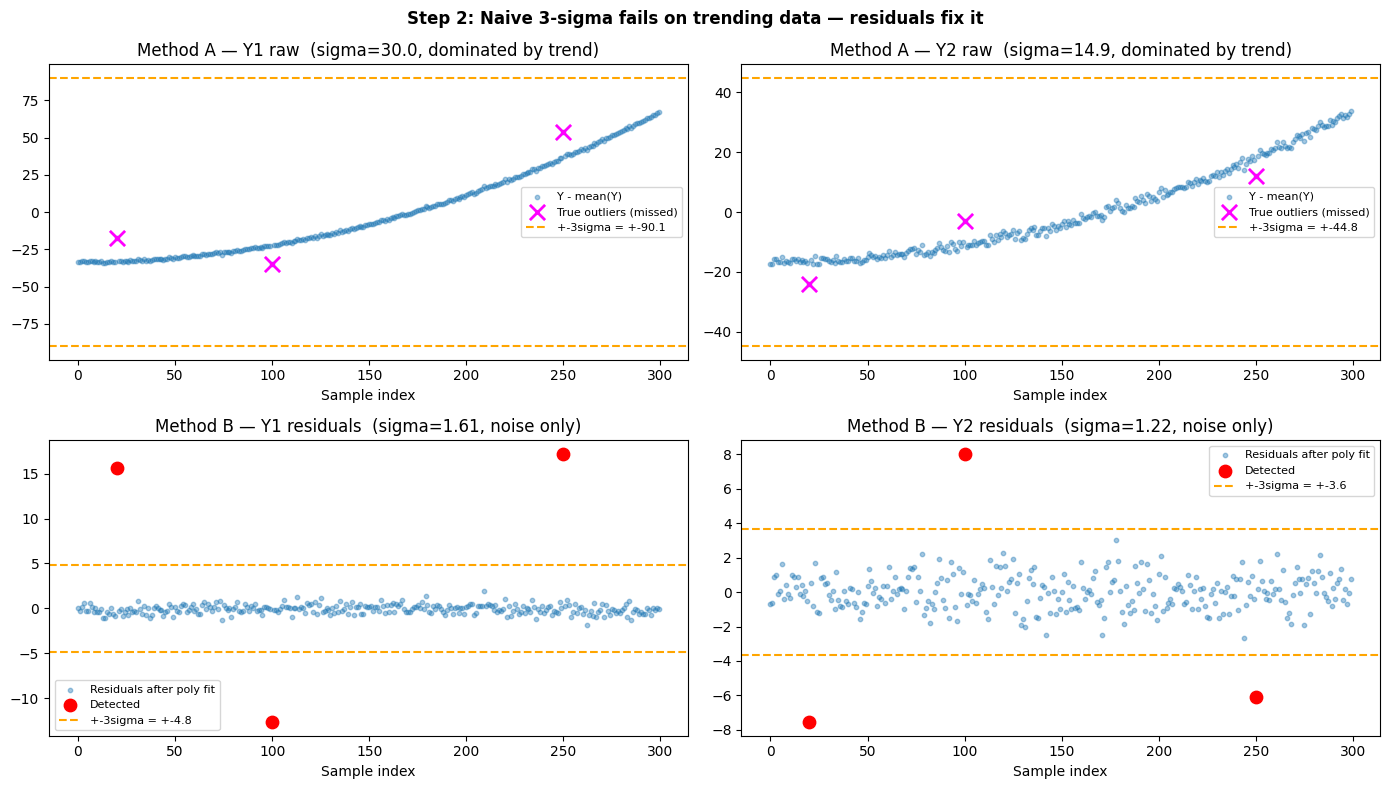

Data after filtering: 297 points (out of 300)


In [9]:
# Side-by-side comparison plot
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for i in range(2):
    label = f'Y{i+1}'

    # Top row: naive method
    ax = axes[0, i]
    ax.scatter(range(n_samples), Y_multi[:, i] - y_mean_raw[i], alpha=0.4, s=10, label='Y - mean(Y)')
    ax.scatter([20, 100, 250], (Y_multi - y_mean_raw)[[20, 100, 250], i],
               color='magenta', marker='x', s=120, linewidths=2, zorder=6, label='True outliers (missed)')
    ax.axhline( 3 * y_std_raw[i], color='orange', linestyle='--', label=f'+-3sigma = +-{3*y_std_raw[i]:.1f}')
    ax.axhline(-3 * y_std_raw[i], color='orange', linestyle='--')
    ax.set_title(f'Method A — {label} raw  (sigma={y_std_raw[i]:.1f}, dominated by trend)')
    ax.set_xlabel('Sample index')
    ax.legend(fontsize=8)

    # Bottom row: residual method
    ax = axes[1, i]
    ax.scatter(range(n_samples), residuals_prelim[:, i], alpha=0.4, s=10, label='Residuals after poly fit')
    ax.scatter(np.where(is_outlier)[0], residuals_prelim[is_outlier, i],
               color='red', s=80, zorder=5, label='Detected')
    ax.axhline( 3 * res_std[i], color='orange', linestyle='--', label=f'+-3sigma = +-{3*res_std[i]:.1f}')
    ax.axhline(-3 * res_std[i], color='orange', linestyle='--')
    ax.set_title(f'Method B — {label} residuals  (sigma={res_std[i]:.2f}, noise only)')
    ax.set_xlabel('Sample index')
    ax.legend(fontsize=8)

plt.suptitle("Step 2: Naive 3-sigma fails on trending data — residuals fix it", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Keep only clean data
X_clean = X_selected[~is_outlier]
Y_clean = Y_multi[~is_outlier]
print(f"Data after filtering: {len(X_clean)} points (out of {n_samples})")

## Steps 3 & 4 — Train/Test Split, then Normalize X and Y

> **Always split *before* fitting any scaler.**

Normalizing on the full dataset first lets test-set statistics contaminate training → **Data Leakage** → overly optimistic metrics.

### X normalization — inside the Pipeline
The `StandardScaler` is the first step of the Pipeline. It is `fit()` only on `X_train`  
when `model.fit()` is called. Completely transparent: you pass raw X, the Pipeline handles the rest.

### Y normalization — outside the Pipeline (separate `y_scaler`)
**Why normalize Y?**
- Puts all outputs on the same scale (critical when Y1 ~ 0–100, Y2 ~ 0–50)
- Prevents Ridge from over-penalizing large-scale outputs
- Required by many algorithms (SVMs, neural networks)

`y_scaler` is `fit()` on `y_train` **only**, then used to `transform` `y_test`.  
After prediction, call `y_scaler.inverse_transform()` to get back physical units.


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, Y_clean, test_size=0.2, random_state=42
)

# Normalize Y — fit on train only
y_scaler       = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train)   # fit + transform
y_test_scaled  = y_scaler.transform(y_test)        # transform only (never fit on test!)

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")
print(f"y_scaler mean  : {np.round(y_scaler.mean_,  2)}")
print(f"y_scaler scale : {np.round(y_scaler.scale_, 2)}")
print(f"y_train_scaled range: [{y_train_scaled.min():.2f}, {y_train_scaled.max():.2f}]  (centered, unit variance)")

Train size: 237 | Test size: 60
y_scaler mean  : [33.95 16.93]
y_scaler scale : [29.82 14.94]
y_train_scaled range: [-1.19, 2.25]  (centered, unit variance)


## Step 5 — Intrinsic Dimensionality Analysis (SVD)

SVD decomposes the Y matrix into orthogonal components ordered by captured variance. The singular values S1, S2... indicate how many dimensions are truly needed.

Interpretation: if $S_2 \ll S_1$ (e.g., ratio < 0.1), it indicates that $Y_2$ is essentially proportional to $Y_1$ ($Y_2 \approx 0.5 \cdot Y_1$), and the underlying physical problem is effectively 1D. While this toy model is simplified for demonstration, real-world applications typically exhibit a larger number of significant singular values depending on the complexity of the coupled physics.

**Note:** Y is already normalized (`y_train_scaled`). SVD is run directly on it.

> If the intrinsic dimension is low (20–30 significant eigenvalues), prefer simple methods. The number of monomials in a polynomial method will be close to the number of significant singular values.

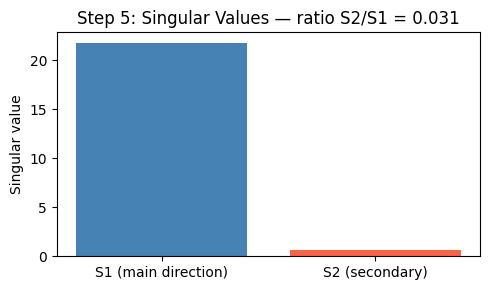

S1 = 21.76, S2 = 0.68, ratio = 0.031
-> S2/S1 << 1: problem is essentially 1D (Y2 ~= 0.5 * Y1)


In [19]:
u, s, vh = np.linalg.svd(y_train_scaled, full_matrices=False)

plt.figure(figsize=(5, 3))
plt.bar(['S1 (main direction)', 'S2 (secondary)'], s, color=['steelblue', 'tomato'])
plt.title(f'Step 5: Singular Values — ratio S2/S1 = {s[1]/s[0]:.3f}')
plt.ylabel('Singular value')
plt.tight_layout()
plt.show()

print(f"S1 = {s[0]:.2f}, S2 = {s[1]:.2f}, ratio = {s[1]/s[0]:.3f}")
print(f"-> S2/S1 << 1: problem is essentially 1D (Y2 ~= 0.5 * Y1)")

## Step 6 — Regularized Polynomial Regression (Pipeline)

**Pipeline architecture:**
1. `StandardScaler` — X normalization (fit on train only, automatic)
2. `PolynomialFeatures(degree=2)` — generate monomials X, X²
3. `Ridge(alpha)` — regularized linear regression (L2 penalty)

**Role of α:**
- α reflects the **noise level** in the data
- α too small → overfits numerical noise
- α too large → underfits, ignores the physics
- **Method:** increase α until you observe an impact on test R²

> The model is trained on **scaled Y** (`y_train_scaled`).  
> R² is evaluated on **physical Y** (after `inverse_transform`) for interpretability.


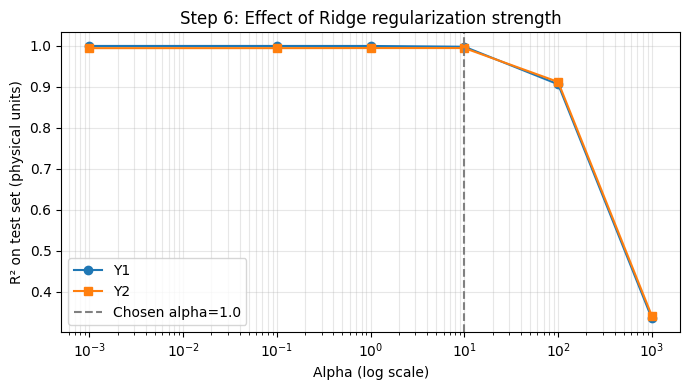

In [17]:
alphas = [0.001, 0.1, 1.0, 10.0, 100.0, 1000.0]
r2_by_alpha = []

for alpha in alphas:
    m = Pipeline([
        ("scaler", StandardScaler()),
        ("poly",   PolynomialFeatures(degree=2)),
        ("ridge",  Ridge(alpha=alpha))
    ])
    m.fit(X_train, y_train_scaled)                               # train on scaled Y
    y_pred_phys = y_scaler.inverse_transform(m.predict(X_test))  # evaluate in physical units
    r2_by_alpha.append(r2_score(y_test, y_pred_phys, multioutput='raw_values'))

r2_by_alpha = np.array(r2_by_alpha)

plt.figure(figsize=(7, 4))
plt.semilogx(alphas, r2_by_alpha[:, 0], 'o-', label='Y1')
plt.semilogx(alphas, r2_by_alpha[:, 1], 's-', label='Y2')
plt.axvline(10.0, color='gray', linestyle='--', label='Chosen alpha=1.0')
plt.xlabel('Alpha (log scale)')
plt.ylabel('R² on test set (physical units)')
plt.title('Step 6: Effect of Ridge regularization strength')
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
# Final model — trained on scaled Y
model = Pipeline([
    ("scaler", StandardScaler()),
    ("poly",   PolynomialFeatures(degree=2)),
    ("ridge",  Ridge(alpha=10.))
])
model.fit(X_train, y_train_scaled)

y_pred_scaled = model.predict(X_test)
y_pred        = y_scaler.inverse_transform(y_pred_scaled)  # back to physical units
print("Model trained.")

Model trained.


## Step 7 — Residual Histogram Analysis

A good model should have residuals that look like **white noise**:
- Centered around zero (no systematic bias)
- Approximately Gaussian (no heavy tails)
- No visible structure (errors are random)

If residuals show structure, this indicates either:
- a **physical non-linearity** not captured (increase polynomial degree)
- **residual outliers** (strengthen the filtering in Step 2)

> **Residuals are computed in physical units** (y_test vs y_pred after `inverse_transform`) so that the error magnitude is directly interpretable.

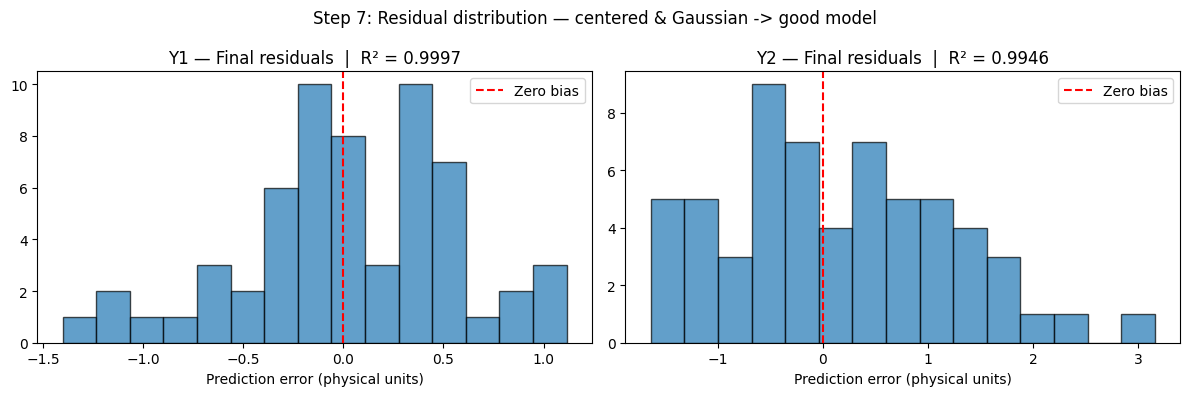

Final R²: Y1 = 0.9997, Y2 = 0.9946


In [14]:
residuals_final = y_test - y_pred   # both in physical units
r2_final = r2_score(y_test, y_pred, multioutput="raw_values")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i in range(2):
    axes[i].hist(residuals_final[:, i], bins=15, edgecolor="black", alpha=0.7)
    axes[i].axvline(0, color='red', linestyle='--', label='Zero bias')
    axes[i].set_title(f"Y{i+1} — Final residuals  |  R² = {r2_final[i]:.4f}")
    axes[i].set_xlabel("Prediction error (physical units)")
    axes[i].legend()
plt.suptitle("Step 7: Residual distribution — centered & Gaussian -> good model")
plt.tight_layout()
plt.show()

print(f"Final R²: Y1 = {r2_final[0]:.4f}, Y2 = {r2_final[1]:.4f}")

## Step 8 — Prediction on New Data & Denormalization

> ⚠️ **Never forget `inverse_transform`** — without it, you get dimensionless scaled outputs instead of physical values.

Full prediction workflow in production:

```
raw X  →  [Pipeline: scale X]  →  model  →  scaled Y  →  [inverse_transform]  →  physical Y
```

| Step | Operation | Who handles it |
|---|---|---|
| X normalization | `(X_raw - mean_X) / scale_X` | Pipeline (automatic) |
| Prediction | `Ridge(scaled_X_poly)` | Pipeline (automatic) |
| Y denormalization | `Y_norm * scale_Y + mean_Y` | **you** (manual call) |




In [15]:
X_new_raw = np.array([
    [1.0],   # expected Y1 ~  1.0² =  1.00
    [5.0],   # expected Y1 ~  5.0² = 25.00
    [9.5],   # expected Y1 ~  9.5² = 90.25
])

# Step-by-step breakdown (shown explicitly)
scaler_x     = model.named_steps["scaler"]
X_new_norm   = scaler_x.transform(X_new_raw)            # 1. normalize X (what Pipeline does internally)
Y_new_scaled = model.predict(X_new_raw)                  # 2. predict in scaled Y space
Y_new_phys   = y_scaler.inverse_transform(Y_new_scaled)  # 3. denormalize -> physical units

print("Step 8: Full prediction pipeline")
print(f"  X scaler : mean={scaler_x.mean_[0]:.3f}, scale={scaler_x.scale_[0]:.3f}")
print(f"  Y scaler : mean={np.round(y_scaler.mean_, 2)}, scale={np.round(y_scaler.scale_, 2)}")
print()
print(f"  {'X_raw':>6}  {'X_norm':>8}  {'Y1_scaled':>10}  {'Y1_phys':>10}  {'Y1_true (X²)':>14}")
print("  " + "-" * 58)
for xr, xn, ys, yp in zip(X_new_raw.flatten(), X_new_norm.flatten(), Y_new_scaled, Y_new_phys):
    print(f"  {xr:>6.1f}  {xn:>8.3f}  {ys[0]:>10.4f}  {yp[0]:>10.3f}  {xr**2:>14.3f}")

Step 8: Full prediction pipeline
  X scaler : mean=5.066, scale=2.881
  Y scaler : mean=[33.95 16.93], scale=[29.82 14.94]

   X_raw    X_norm   Y1_scaled     Y1_phys    Y1_true (X²)
  ----------------------------------------------------------
     1.0    -1.411     -1.1045       1.013           1.000
     5.0    -0.023     -0.2968      25.099          25.000
     9.5     1.539      1.8783      89.958          90.250


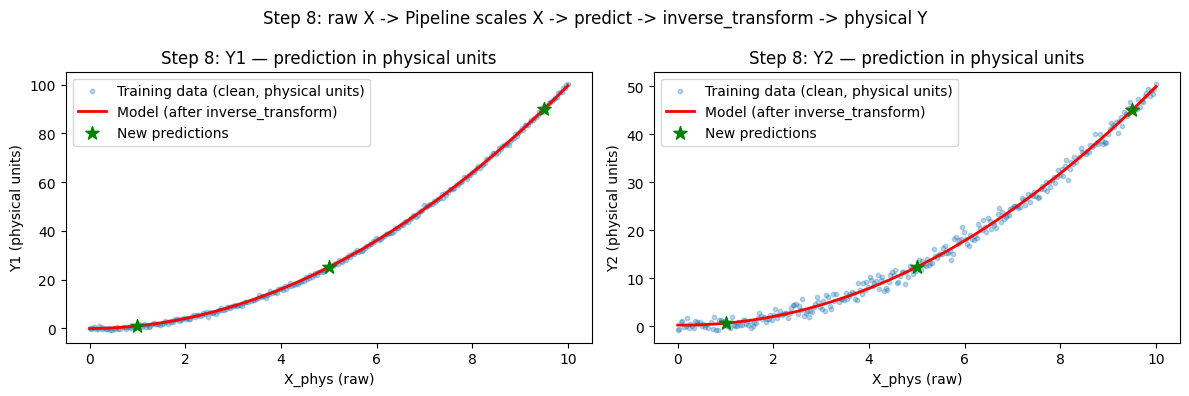

In [16]:
# Visual check: model curve vs training data
X_plot      = np.linspace(0, 10, 200).reshape(-1, 1)
Y_plot_phys = y_scaler.inverse_transform(model.predict(X_plot))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i in range(2):
    axes[i].scatter(X_clean, Y_clean[:, i], alpha=0.3, s=10, label='Training data (clean, physical units)')
    axes[i].plot(X_plot, Y_plot_phys[:, i], color='red', linewidth=2, label='Model (after inverse_transform)')
    axes[i].scatter(X_new_raw, Y_new_phys[:, i], color='green', s=100, zorder=5, marker='*', label='New predictions')
    axes[i].set_title(f'Step 8: Y{i+1} — prediction in physical units')
    axes[i].set_xlabel('X_phys (raw)')
    axes[i].set_ylabel(f'Y{i+1} (physical units)')
    axes[i].legend()
plt.suptitle("Step 8: raw X -> Pipeline scales X -> predict -> inverse_transform -> physical Y")
plt.tight_layout()
plt.show()